# NCAA tournament probability forecasting
## From controlled research to a scored margin ensemble
**Alvaro Mendizabal | September 2026**

This clean-kernel report reads committed aggregate evidence only. No fitting, downloads, cloud access or submissions occur. The achieved late score and the unsubmitted women’s experiment are kept separate.

In [1]:
from pathlib import Path
import sys
root=Path.cwd()
if not (root/'portfolio').is_dir(): root=root.parent
sys.path.insert(0,str(root/'portfolio'))
from current_research import load_evidence,load_progression,chart
import pandas as pd
from IPython.display import display
e=load_evidence();d=load_progression();r=e['robustness'];s=d['scored'];w=d['women_screen']
display(pd.DataFrame([{'Evaluation':'Recorded late submission','Brier':s['candidate_score'],'Status':'COMPLETE; not an original placement'},{'Evaluation':'Women screen: 504 historical games','Brier':w['screen_margin_brier'],'Status':'Unsubmitted; fuller-ensemble review'}]))

,Evaluation,Brier,Status
0,Recorded late submission,0.109490,COMPLETE; not an original placement
1,Women screen: 504 historical games,0.138776,Unsubmitted; fuller-ensemble review


## 1. What actually improved the scored result?
The fixed men’s margin blend scored **0.1094899**, versus its predecessor’s **0.1098691**. The first-place author reports **0.1097454 on 126 games**. Our late score is numerically lower by **0.0002555**; this is not retroactive first place or statistically established prospective superiority. The source receipt identifies submission **56447505** and the exact prediction-file hash.

,Improvement over predecessor,Amount below published number,Submission reference
0,0.000379,0.000256,56447505


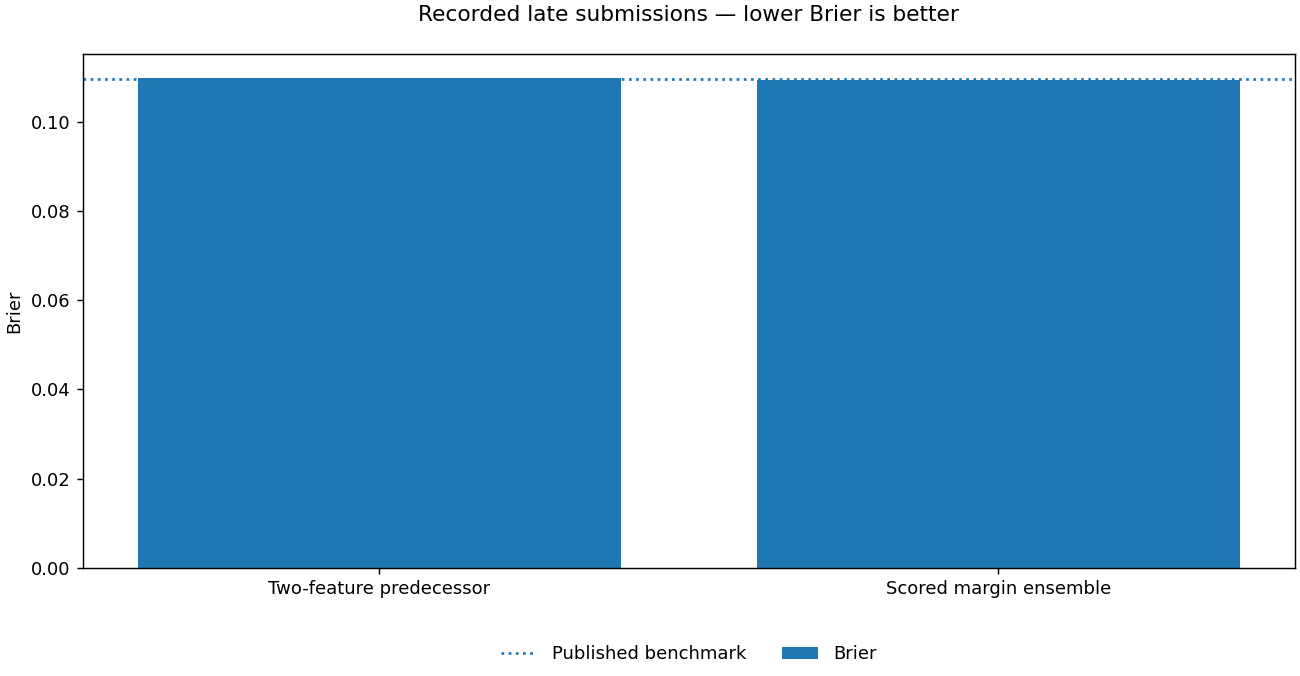

In [2]:
display(pd.DataFrame([{'Improvement over predecessor':s['gain_vs_incumbent'],'Amount below published number':-s['gap_to_published_benchmark'],'Submission reference':s['submission_ref']}]))
chart('scored','Recorded late submissions — lower Brier is better',['Two-feature predecessor','Scored margin ensemble'],{'Brier':[s['incumbent_score'],s['candidate_score']]},'Brier',s['benchmark'])

The build made one upload. Its 132,133-row output changed only 2,278 seeded-men matchups, preserving 129,855 other lines, including all 65,703 women’s lines. The scored CSV stays outside this publication. Its hash and the aggregate verification record are committed; no credential or raw training data is published.

## 2. Negative findings narrowed the hypothesis
Full feature union, residual PCA, nested subset selection and frozen-core correction failed to improve the common men’s historical screen. We then changed the target from signed win/loss to actual point margin, keeping representation and training matched. A close win and a large win no longer give identical supervision. This is a tested mechanism, not an assumption that regression always helps.

,experiment,core,candidate,decision,gain
0,Full feature bundle,0.186664,0.189996,Rejected,-0.003332
1,Residual PCA bundle,0.186664,0.189000,Rejected,-0.002336
2,Nested subset selection,0.186664,0.187789,Rejected,-0.001125
3,Frozen-core feature correction,0.186664,0.187130,Rejected,-0.000466
4,Fixed 25% rich margin blend,0.186664,0.185529,Advanced to robustness,0.001135


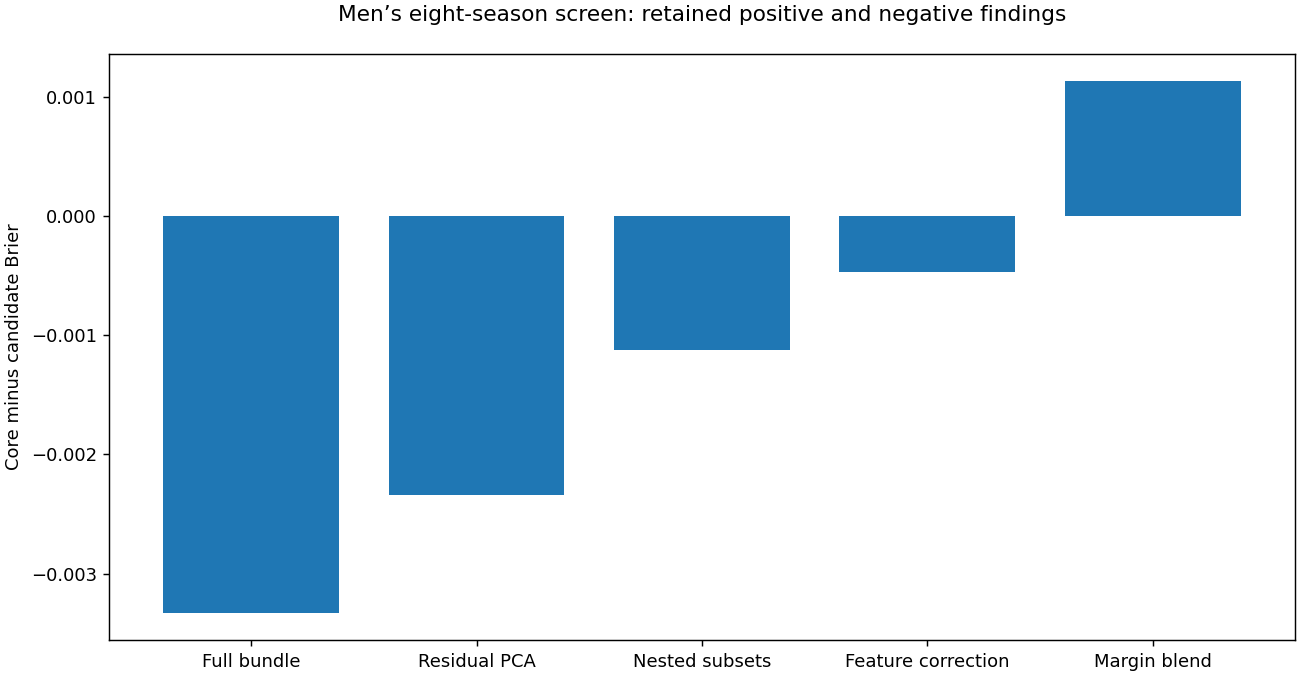

In [3]:
screen=pd.DataFrame(e['screen']['rows']);screen['gain']=screen['core']-screen['candidate']
display(screen)
chart('screen','Men’s eight-season screen: retained positive and negative findings',['Full bundle','Residual PCA','Nested subsets','Feature correction','Margin blend'],{'Brier reduction':screen['gain'].tolist()},'Core minus candidate Brier')

## 3. Historical support before the score test
The men’s fuller ensemble uses 33 inputs, three predeclared seeds, whole-season inner omissions, fold-local transformations, and a fixed 75% core / 25% auxiliary blend. A matched binary target controls for added model capacity. Outer years remain excluded from fitting; reused development years are not independent confirmation.

,core,binary,margin
0,0.179505,0.177882,0.177465


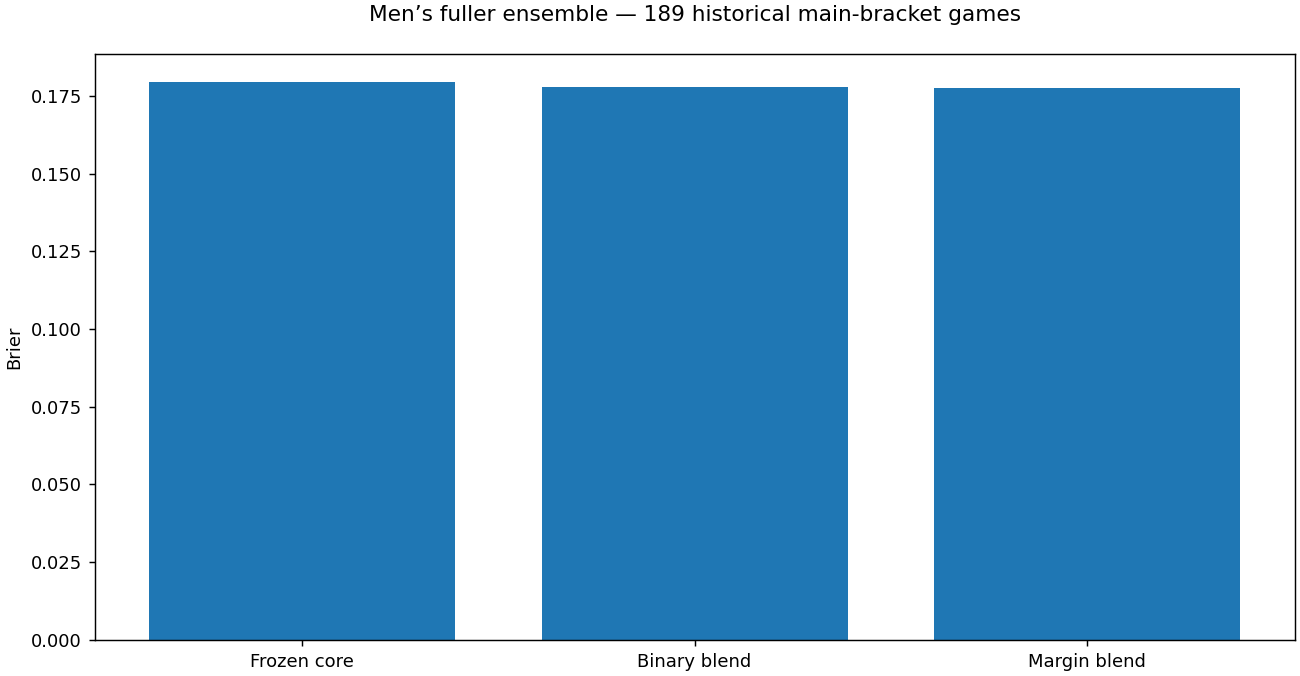

In [4]:
p=r['pooled'];display(pd.DataFrame([p]))
chart('pooled','Men’s fuller ensemble — 189 historical main-bracket games',['Frozen core','Binary blend','Margin blend'],{'Brier':[p['core'],p['binary'],p['margin']]},'Brier')

,year,games,core,binary,margin
0,2023,63,0.209928,0.208175,0.207977
1,2024,63,0.188468,0.187603,0.186258
2,2025,63,0.140118,0.137867,0.138159


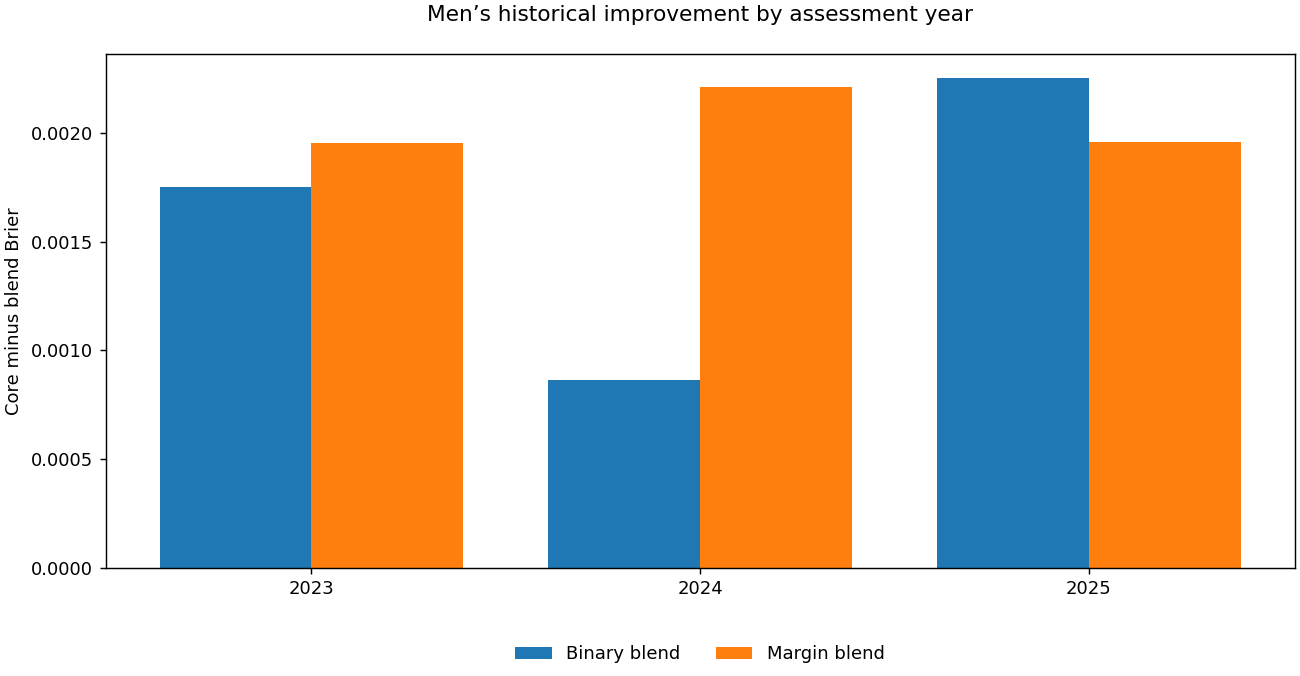

In [5]:
years=pd.DataFrame(r['rows']);display(years)
chart('years','Men’s historical improvement by assessment year',years.year.astype(str).tolist(),{'Binary blend':(years.core-years.binary).tolist(),'Margin blend':(years.core-years.margin).tolist()},'Core minus blend Brier')

,seed,brier,gain
0,20260921,0.177363,0.002141
1,20260922,0.177548,0.001957
2,20260923,0.177485,0.002020


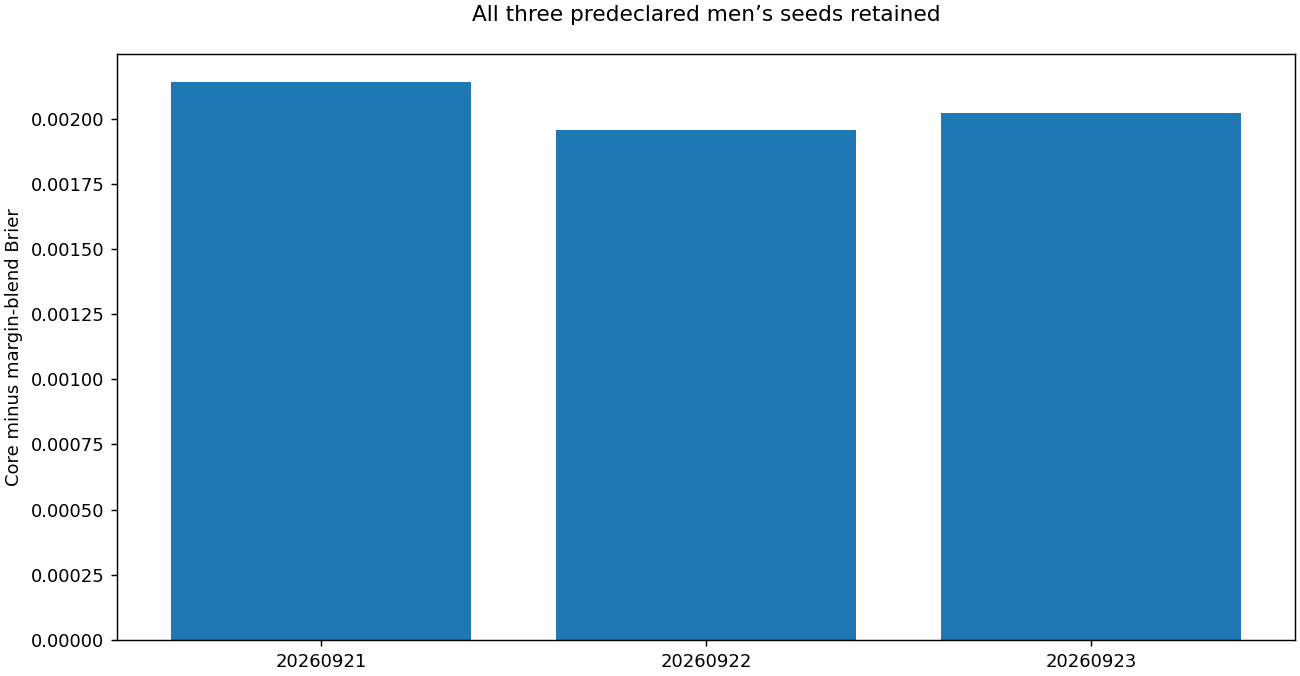

In [6]:
seeds=pd.DataFrame(r['seeds']);seeds['gain']=p['core']-seeds.brier;display(seeds)
chart('seeds','All three predeclared men’s seeds retained',seeds.seed.astype(str).tolist(),{'Brier reduction':seeds.gain.tolist()},'Core minus margin-blend Brier')

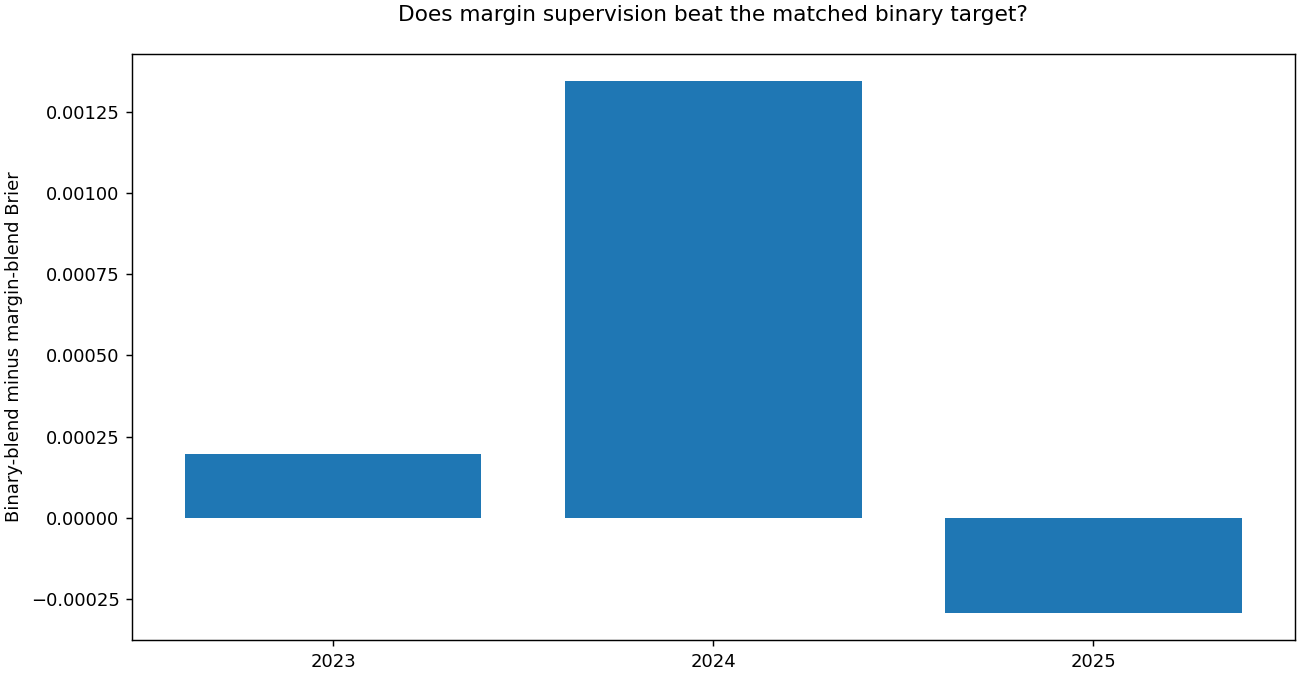

In [7]:
chart('ablation','Does margin supervision beat the matched binary target?',years.year.astype(str).tolist(),{'Margin advantage':(years.binary-years.margin).tolist()},'Binary-blend minus margin-blend Brier')

The margin blend improves the stronger core in all three years and for all three seeds. It beats the matched binary blend in two of three years, not uniformly. The 360-fit robustness result preceded a 66-fit candidate build and a single score test. None of those model fits is repeated by this report.

## 4. Can the mechanism transfer to women?
The separate women’s experiment uses its own four-feature core plus 28 auxiliary differences. No women’s Massey or men-only AP inputs are invented. One fixed 25% margin blend is compared with its matched binary-target control on **504 games across eight historical seasons**. Existing scored predictions remain untouched.

,Core,Binary blend,Margin blend,Gain,Gain over binary
0,0.140529,0.140227,0.138776,0.001754,0.001451


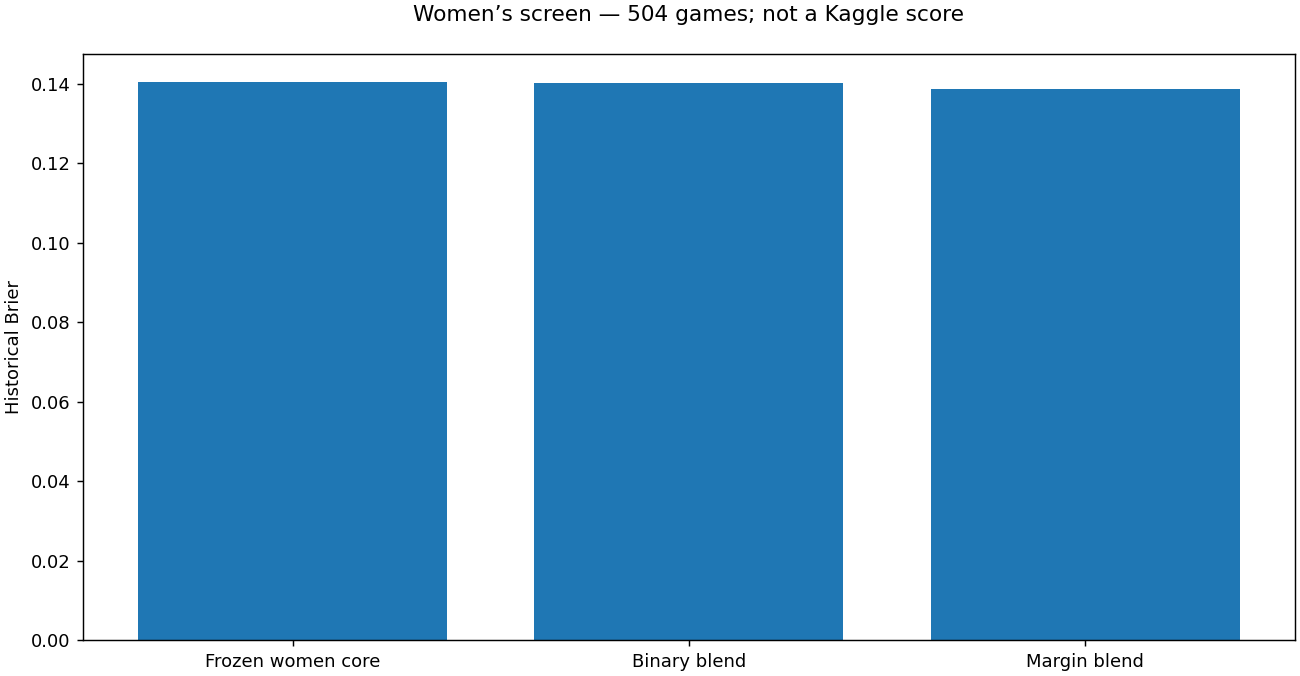

In [8]:
display(pd.DataFrame([{'Core':w['screen_core_brier'],'Binary blend':w['screen_binary_brier'],'Margin blend':w['screen_margin_brier'],'Gain':w['screen_gain'],'Gain over binary':w['objective_gain']}]))
chart('women','Women’s screen — 504 games; not a Kaggle score',['Frozen women core','Binary blend','Margin blend'],{'Brier':[w['screen_core_brier'],w['screen_binary_brier'],w['screen_margin_brier']]},'Historical Brier')

,year,games,baseline_brier,candidate_brier,gain
0,2017,63,0.133976,0.133720,0.000256
1,2018,63,0.162451,0.157996,0.004455
2,2019,63,0.132465,0.131236,0.001229
3,2021,63,0.147703,0.148401,-0.000699
4,2022,63,0.154179,0.149777,0.004403
5,2023,63,0.182742,0.179955,0.002787
6,2024,63,0.109604,0.110464,-0.000860
7,2025,63,0.101114,0.098656,0.002458


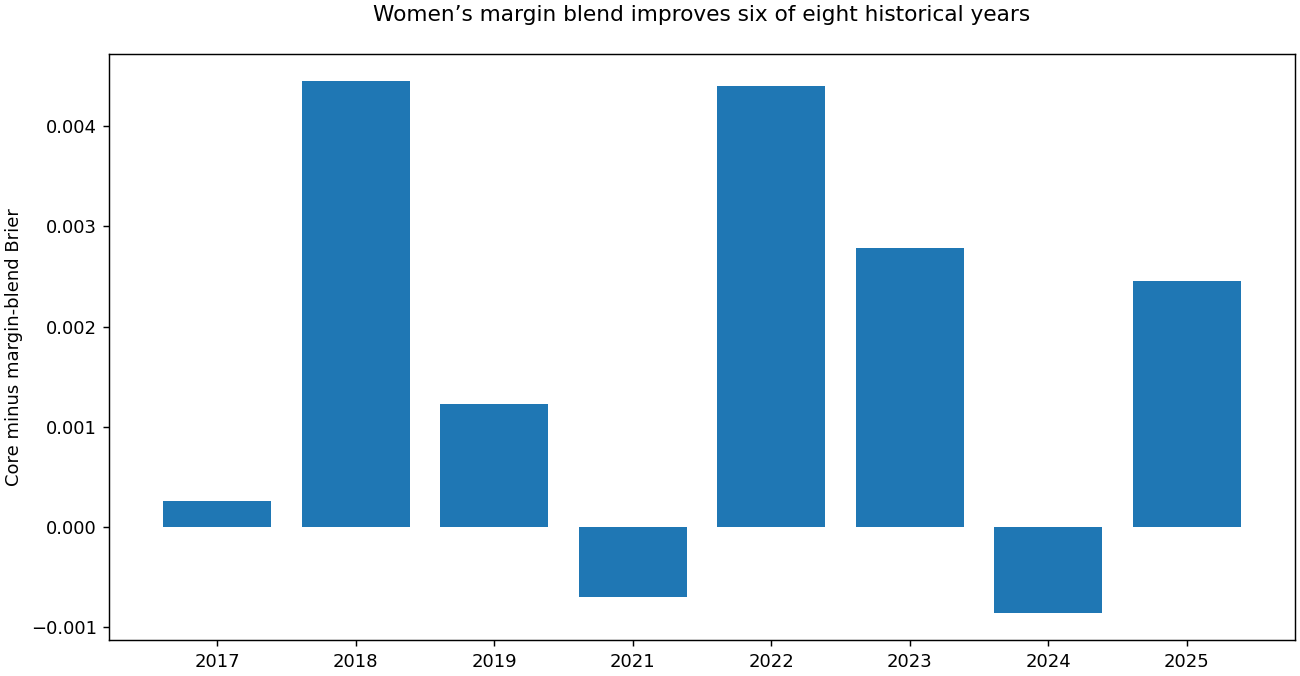

,year,games,baseline_brier,candidate_brier,gain
0,2023,63,0.179331,0.177369,0.001962
1,2024,63,0.115484,0.114817,0.000667
2,2025,63,0.092826,0.092468,0.000358


In [9]:
wy=pd.DataFrame(w['rows']);display(wy)
chart('women_years','Women’s margin blend improves six of eight historical years',wy.year.astype(str).tolist(),{'Brier reduction':wy.gain.tolist()},'Core minus margin-blend Brier')
display(pd.DataFrame(w['full_reference_rows']))

The women’s screen improves Brier by **0.0017536** and beats its matched binary control by **0.0014509**. Against the retained stronger 2023–2025 core, the same screened margin forecasts improve Brier from **0.1292138 to 0.1282181**, with gains in all three years. That is not yet a full margin ensemble: it motivates the next fuller-ensemble test. All eight screening checks passed in an 18.80-second run with 48 tree fits and 46 regression tests.

In [10]:
display(pd.DataFrame([{'Check':k,'Passed':v} for k,v in w['checks'].items()]))
print('Women decision:',w['decision'])
print('Women candidate Kaggle score:',w['new_kaggle_score'])

,Check,Passed
0,all_tournament_guard,True
1,beats_matched_binary,True
2,conditional_support,True
3,full_recipe_reference,True
4,historical_gain,True
5,recent_guard,True
6,season_stability,True
7,worst_season_guard,True


Women decision: FULL_RECIPE_REVIEW
Women candidate Kaggle score: None


## 5. Limits, provenance and the next decision
Historical years were reused, hypotheses were selected sequentially, and inner held-out scores served early stopping and calibration. Bootstrap support is conditional, not selection-adjusted. Seeds measure numerical stability, not independent tournaments. The men’s late score motivated the women’s hypothesis, but 2026 outcomes are excluded from fitting.

**Completed:** scored men’s margin release, protected-row validation, women’s bounded screen and this publication. **Next:** three-seed, whole-season-omission women’s robustness at the same fixed blend. A later candidate build and separately authorized scoring require that decision first. No worthy new submission is claimed before it exists.

GitHub contains the evidence, report code, tests and saved plots. AWS retains full experiment sources, authorized raw records, feature caches, models and local changes. Re-executing this report reproduces aggregate analyses, not model training. Historical evidence.json is preserved; progression.json records the newer score and women’s result. Credit and limitations are in docs/current_research.md.

In [11]:
print('REPORT_COMPLETE — aggregate evidence only; zero training or submissions')

REPORT_COMPLETE — aggregate evidence only; zero training or submissions
